In [2]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
df = pd.read_feather('/content/Clustering_Data.ftr')

print("Dataset loaded successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Clustering_Data.ftr'

In [ ]:
df.head()

,Customer_ID,Street,City,State_Code,Postal_Code,Country,Seasonality_Segment,EA_Segment,Revenue_Bucket,Profit_Bucket,Market_Share_Segment,Casino_Size_Segment,Market_Potential_Segment,Churn_Segment,Competitiveness_Flag,Volume_Segment,Density_Segment,Propensity
0,Accoount 1,2295 BATTLEFORD RD,MISSISSAUGA,ON,L5N 2W8,CAN,None,None,None,None,None,None,None,None,Yes,High,High,-
1,Accoount 2,64 WESTBANK EXPY STE A,GRETNA,LA,70053,USA,None,None,None,None,None,None,None,None,-,Medium,Medium,-
2,Accoount 3,209-229 E Airline Hwy.,LaPlace,LA,70068,USA,None,None,None,None,None,None,None,None,-,Medium,Medium,-
3,Accoount 4,500 S MEADOWS PKWY,RENO,NV,89521,USA,None,None,None,None,None,None,None,None,Yes,High,High,-
4,Accoount 5,746 Victorian Avenue,Sparks,NV,89431,USA,None,None,None,None,None,None,None,None,Yes,High,High,-


In [ ]:
df.shape

(3030, 18)

In [ ]:
df.columns

Index(['Customer_ID', 'Street', 'City', 'State_Code', 'Postal_Code', 'Country',
       'Seasonality_Segment', 'EA_Segment', 'Revenue_Bucket', 'Profit_Bucket',
       'Market_Share_Segment', 'Casino_Size_Segment',
       'Market_Potential_Segment', 'Churn_Segment', 'Competitiveness_Flag',
       'Volume_Segment', 'Density_Segment', 'Propensity'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Customer_ID               3030 non-null   object
 1   Street                    3029 non-null   object
 2   City                      3030 non-null   object
 3   State_Code                2722 non-null   object
 4   Postal_Code               3030 non-null   object
 5   Country                   3030 non-null   object
 6   Seasonality_Segment       2282 non-null   object
 7   EA_Segment                2841 non-null   object
 8   Revenue_Bucket            3030 non-null   object
 9   Profit_Bucket             3030 non-null   object
 10  Market_Share_Segment      3030 non-null   object
 11  Casino_Size_Segment       3030 non-null   object
 12  Market_Potential_Segment  3030 non-null   object
 13  Churn_Segment             3030 non-null   object
 14  Competitiveness_Flag    

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Street,1
City,0
State_Code,308
Postal_Code,0
Country,0
Seasonality_Segment,748
EA_Segment,189
Revenue_Bucket,0
Profit_Bucket,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Customer_ID'].duplicated().sum()

np.int64(0)

In [ ]:
for col in df.columns:
    print("\n==============================")
    print(col)
    print("==============================")
    print(df[col].value_counts(dropna=False).head(15))


Customer_ID
Customer_ID
Accoount 3030    1
Accoount 1       1
Accoount 2       1
Accoount 3       1
Accoount 4       1
Accoount 5       1
Accoount 3014    1
Accoount 3013    1
Accoount 3012    1
Accoount 3011    1
Accoount 3010    1
Accoount 3009    1
Accoount 3008    1
Accoount 3007    1
Accoount 3006    1
Name: count, dtype: int64

Street
Street
No Address Found                220
3655 NW 87TH AVE                 67
10220 ARISTOCRAT WAY             42
1050 CARIBBEAN WAY               39
7665 CORPORATE CENTER DR         20
6301 E 10TH AVE STE 160          16
10220 Aristocrat Way             12
6850 AUSTIN CENTER BLVD #350     10
7665 Corporate Center Drive       9
887 TRADEMARK DRIVE               7
500 NW 32ND ST                    6
308 MALLORY STATION ROAD          6
2300 Rock Springs Drive           6
37 Billy Folly Road               4
2935 W CORPORATE LAKES BLVD       4
Name: count, dtype: int64

City
City
LAS VEGAS           351
No Address Found    195
MIAMI               141


In [ ]:
summary = pd.DataFrame({
    'Data_Type': df.dtypes,
    'Unique_Values': df.nunique(),
    'Missing_Values': df.isnull().sum(),
    'Missing_%': (df.isnull().sum() / len(df) * 100).round(2)
})

summary

,Data_Type,Unique_Values,Missing_Values,Missing_%
Customer_ID,object,3030,0,0.00
Street,object,2461,1,0.03
City,object,1245,0,0.00
State_Code,object,60,308,10.17
Postal_Code,object,1124,0,0.00
Country,object,33,0,0.00
Seasonality_Segment,object,4,748,24.69
EA_Segment,object,4,189,6.24
Revenue_Bucket,object,4,0,0.00
Profit_Bucket,object,4,0,0.00


In [ ]:
cluster_cols = [
    'Seasonality_Segment',
    'EA_Segment',
    'Revenue_Bucket',
    'Profit_Bucket',
    'Market_Share_Segment',
    'Casino_Size_Segment',
    'Market_Potential_Segment',
    'Churn_Segment',
    'Competitiveness_Flag',
    'Volume_Segment',
    'Density_Segment',
    'Propensity'
]

for col in cluster_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


Seasonality_Segment:
Seasonality_Segment
None                    1579
None                     748
Potentially Seasonal     455
Highly Seasonal          142
Non Seasonal             106
Name: count, dtype: int64

EA_Segment:
EA_Segment
None              2356
Early Adopter      285
None               189
Late Adopter       107
Trend Follower      93
Name: count, dtype: int64

Revenue_Bucket:
Revenue_Bucket
None    1954
L        743
M        256
H         77
Name: count, dtype: int64

Profit_Bucket:
Profit_Bucket
None    1954
H        985
L         72
M         19
Name: count, dtype: int64

Market_Share_Segment:
Market_Share_Segment
None    2138
M        566
H        169
L        157
Name: count, dtype: int64

Casino_Size_Segment:
Casino_Size_Segment
None    2138
L        479
M        288
H        125
Name: count, dtype: int64

Market_Potential_Segment:
Market_Potential_Segment
None    2138
M        358
H        306
L        121
VH       107
Name: count, dtype: int64

Churn_Segment:
Chu

In [ ]:
print("Actual missing values:")
print(df.isna().sum())

print("\nString 'None' values:")
for col in df.columns:
    count = (df[col] == 'None').sum()
    if count > 0:
        print(col, ":", count)

Actual missing values:
Customer_ID                   0
Street                        1
City                          0
State_Code                  308
Postal_Code                   0
Country                       0
Seasonality_Segment         748
EA_Segment                  189
Revenue_Bucket                0
Profit_Bucket                 0
Market_Share_Segment          0
Casino_Size_Segment           0
Market_Potential_Segment      0
Churn_Segment                 0
Competitiveness_Flag          0
Volume_Segment                0
Density_Segment             405
Propensity                    0
dtype: int64

String 'None' values:
Postal_Code : 421
Seasonality_Segment : 1579
EA_Segment : 2356
Revenue_Bucket : 1954
Profit_Bucket : 1954
Market_Share_Segment : 2138
Casino_Size_Segment : 2138
Market_Potential_Segment : 2138
Churn_Segment : 2022


In [ ]:
print("ACTUAL NaN VALUES")
print("=" * 50)

print(df.isna().sum())

print("\n\nSTRING 'None' VALUES")
print("=" * 50)

for col in df.columns:
    count = (df[col] == 'None').sum()
    if count > 0:
        print(f"{col}: {count}")

print("\n\nSTRING '-' VALUES")
print("=" * 50)

for col in df.columns:
    count = (df[col] == '-').sum()
    if count > 0:
        print(f"{col}: {count}")

ACTUAL NaN VALUES
Customer_ID                   0
Street                        1
City                          0
State_Code                  308
Postal_Code                   0
Country                       0
Seasonality_Segment         748
EA_Segment                  189
Revenue_Bucket                0
Profit_Bucket                 0
Market_Share_Segment          0
Casino_Size_Segment           0
Market_Potential_Segment      0
Churn_Segment                 0
Competitiveness_Flag          0
Volume_Segment                0
Density_Segment             405
Propensity                    0
dtype: int64


STRING 'None' VALUES
Postal_Code: 421
Seasonality_Segment: 1579
EA_Segment: 2356
Revenue_Bucket: 1954
Profit_Bucket: 1954
Market_Share_Segment: 2138
Casino_Size_Segment: 2138
Market_Potential_Segment: 2138
Churn_Segment: 2022


STRING '-' VALUES
Competitiveness_Flag: 1591
Volume_Segment: 623
Density_Segment: 623
Propensity: 2071


In [ ]:
# Count how many of the key business features are unavailable for each customer

business_cols = [
    'Seasonality_Segment',
    'EA_Segment',
    'Revenue_Bucket',
    'Profit_Bucket',
    'Market_Share_Segment',
    'Casino_Size_Segment',
    'Market_Potential_Segment',
    'Churn_Segment',
    'Competitiveness_Flag',
    'Volume_Segment',
    'Density_Segment',
    'Propensity'
]

# Treat NaN, "None" and "-" as unavailable
unavailable = (
    df[business_cols].isna() |
    df[business_cols].isin(['None', '-'])
)

df['Missing_Feature_Count'] = unavailable.sum(axis=1)

df['Missing_Feature_Count'].value_counts().sort_index()

,count
Missing_Feature_Count,
0,164
1,245
2,175
3,135
4,91
5,94
6,107
7,152
8,70


In [ ]:
df['Missing_Feature_Count'].describe()

,Missing_Feature_Count
count,3030.000000
mean,7.435314
std,3.908698
min,0.000000
25%,4.000000
50%,9.000000
75%,10.000000
max,12.000000


In [ ]:
pd.crosstab(
    df['Missing_Feature_Count'],
    df['Country']
).head(20)

Country,ABW,ANT,ARG,AUS,AUT,BES,BHS,BMU,CAN,CHL,...,No Address Found,PAN,PER,PRY,SXM,TCA,URY,USA,VEN,VGB
Missing_Feature_Count,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,11,0,...,0,0,0,0,0,0,0,153,0,0
1,0,0,0,0,0,0,0,0,34,0,...,0,0,0,0,0,0,0,211,0,0
2,0,0,0,0,0,0,0,0,23,0,...,0,0,0,0,0,0,0,152,0,0
3,0,0,0,0,0,0,0,0,17,0,...,0,0,0,0,0,0,0,118,0,0
4,0,0,0,0,0,0,0,0,11,0,...,0,0,0,0,0,0,0,80,0,0
5,0,0,0,0,0,0,0,0,3,0,...,0,0,0,0,0,0,0,91,0,0
6,0,0,0,0,0,0,0,0,8,0,...,0,0,0,0,0,0,0,99,0,0
7,0,0,0,0,0,0,0,0,17,0,...,0,0,0,0,0,0,0,135,0,0
8,0,0,0,0,0,0,0,0,2,0,...,0,0,0,0,0,0,0,68,0,0


In [ ]:
df[
    df['Missing_Feature_Count'] >= 10
][
    ['Customer_ID', 'Country', 'City', 'Missing_Feature_Count']
].head(20)

,Customer_ID,Country,City,Missing_Feature_Count
1,Accoount 2,USA,GRETNA,10
2,Accoount 3,USA,LaPlace,10
6,Accoount 7,USA,CARSON CITY,10
7,Accoount 8,USA,SAINT MARTINVILLE,12
44,Accoount 45,USA,COLORADO SPRINGS,10
61,Accoount 62,PER,MIRAFLORES LIMA,12
62,Accoount 63,CHL,IQIQUE,12
63,Accoount 64,PAN,BELLA VISTA,12
64,Accoount 65,PER,LIMA,12
65,Accoount 66,PER,BARRANCA-LIMA,12


In [ ]:
business_cols = [
    'Seasonality_Segment',
    'EA_Segment',
    'Revenue_Bucket',
    'Profit_Bucket',
    'Market_Share_Segment',
    'Casino_Size_Segment',
    'Market_Potential_Segment',
    'Churn_Segment',
    'Competitiveness_Flag',
    'Volume_Segment',
    'Density_Segment',
    'Propensity'
]

feature_profile = []

for col in business_cols:
    total = len(df)

    missing_nan = df[col].isna().sum()
    missing_none = (df[col] == 'None').sum()
    missing_dash = (df[col] == '-').sum()

    unavailable = missing_nan + missing_none + missing_dash

    feature_profile.append({
        'Feature': col,
        'Unavailable': unavailable,
        'Unavailable_%': round(unavailable / total * 100, 2),
        'Available': total - unavailable,
        'Unique_Available_Values': df.loc[
            ~(
                df[col].isna() |
                df[col].isin(['None', '-'])
            ),
            col
        ].nunique()
    })

feature_profile = pd.DataFrame(feature_profile)

feature_profile.sort_values(
    'Unavailable_%',
    ascending=False
)

,Feature,Unavailable,Unavailable_%,Available,Unique_Available_Values
1,EA_Segment,2545,83.99,485,3
0,Seasonality_Segment,2327,76.80,703,3
5,Casino_Size_Segment,2138,70.56,892,3
4,Market_Share_Segment,2138,70.56,892,3
6,Market_Potential_Segment,2138,70.56,892,4
11,Propensity,2071,68.35,959,3
7,Churn_Segment,2022,66.73,1008,3
2,Revenue_Bucket,1954,64.49,1076,3
3,Profit_Bucket,1954,64.49,1076,3
8,Competitiveness_Flag,1591,52.51,1439,1


In [ ]:
for col in business_cols:

    valid = df[col][
        ~(
            df[col].isna() |
            df[col].isin(['None', '-'])
        )
    ]

    print("\n" + "=" * 50)
    print(col)
    print("=" * 50)
    print(valid.value_counts())


Seasonality_Segment
Seasonality_Segment
Potentially Seasonal    455
Highly Seasonal         142
Non Seasonal            106
Name: count, dtype: int64

EA_Segment
EA_Segment
Early Adopter     285
Late Adopter      107
Trend Follower     93
Name: count, dtype: int64

Revenue_Bucket
Revenue_Bucket
L    743
M    256
H     77
Name: count, dtype: int64

Profit_Bucket
Profit_Bucket
H    985
L     72
M     19
Name: count, dtype: int64

Market_Share_Segment
Market_Share_Segment
M    566
H    169
L    157
Name: count, dtype: int64

Casino_Size_Segment
Casino_Size_Segment
L    479
M    288
H    125
Name: count, dtype: int64

Market_Potential_Segment
Market_Potential_Segment
M     358
H     306
L     121
VH    107
Name: count, dtype: int64

Churn_Segment
Churn_Segment
Minimal Change    929
Encouraging        55
Concerning         24
Name: count, dtype: int64

Competitiveness_Flag
Competitiveness_Flag
Yes    1439
Name: count, dtype: int64

Volume_Segment
Volume_Segment
High      1304
Medium     60

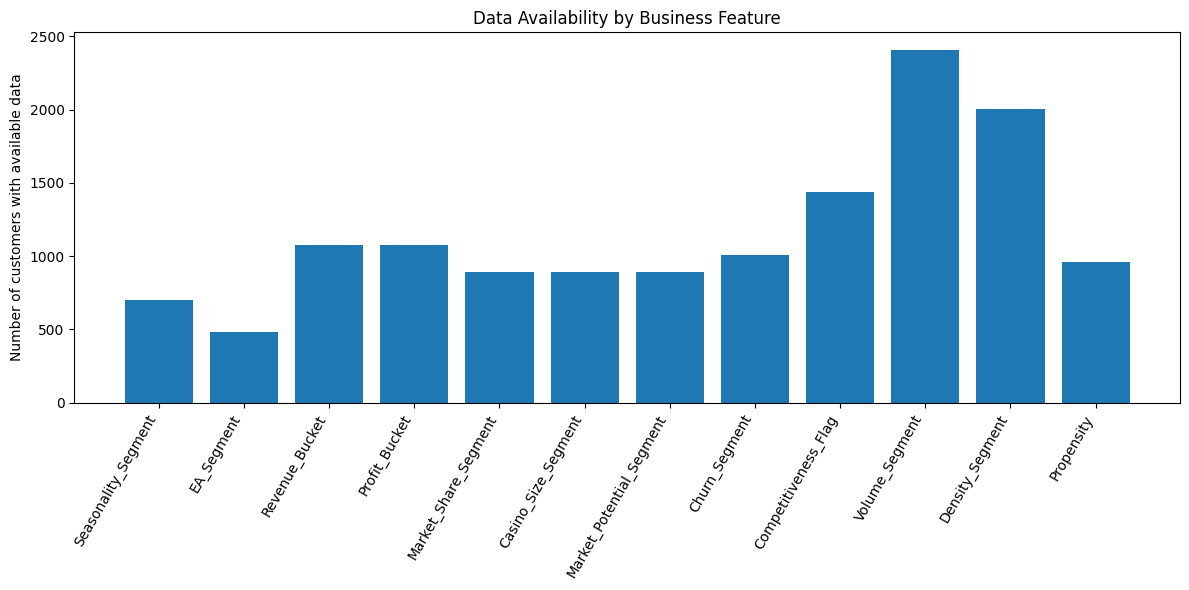

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    feature_profile['Feature'],
    feature_profile['Available']
)

plt.xticks(rotation=60, ha='right')
plt.ylabel('Number of customers with available data')
plt.title('Data Availability by Business Feature')

plt.tight_layout()
plt.show()

In [ ]:
# Check whether features are available for the same customers

availability = pd.DataFrame(index=df.index)

for col in business_cols:
    availability[col] = ~(
        df[col].isna() |
        df[col].isin(['None', '-'])
    )

availability.sum().sort_values()

,0
EA_Segment,485
Seasonality_Segment,703
Casino_Size_Segment,892
Market_Share_Segment,892
Market_Potential_Segment,892
Propensity,959
Churn_Segment,1008
Profit_Bucket,1076
Revenue_Bucket,1076
Competitiveness_Flag,1439


In [ ]:
# Correlation of data availability between features

availability.corr().round(2)

,Seasonality_Segment,EA_Segment,Revenue_Bucket,Profit_Bucket,Market_Share_Segment,Casino_Size_Segment,Market_Potential_Segment,Churn_Segment,Competitiveness_Flag,Volume_Segment,Density_Segment,Propensity
Seasonality_Segment,1.00,0.68,0.69,0.69,0.62,0.62,0.62,0.76,0.06,0.25,0.10,0.68
EA_Segment,0.68,1.00,0.53,0.53,0.48,0.48,0.48,0.59,0.04,0.20,0.06,0.57
Revenue_Bucket,0.69,0.53,1.00,1.00,0.69,0.69,0.69,0.88,0.14,0.35,0.20,0.70
Profit_Bucket,0.69,0.53,1.00,1.00,0.69,0.69,0.69,0.88,0.14,0.35,0.20,0.70
Market_Share_Segment,0.62,0.48,0.69,0.69,1.00,1.00,1.00,0.71,0.06,0.29,0.13,0.64
Casino_Size_Segment,0.62,0.48,0.69,0.69,1.00,1.00,1.00,0.71,0.06,0.29,0.13,0.64
Market_Potential_Segment,0.62,0.48,0.69,0.69,1.00,1.00,1.00,0.71,0.06,0.29,0.13,0.64
Churn_Segment,0.76,0.59,0.88,0.88,0.71,0.71,0.71,1.00,0.07,0.32,0.14,0.72
Competitiveness_Flag,0.06,0.04,0.14,0.14,0.06,0.06,0.06,0.07,1.00,0.48,0.52,0.09
Volume_Segment,0.25,0.20,0.35,0.35,0.29,0.29,0.29,0.32,0.48,1.00,0.71,0.29


In [ ]:
# Calculate how dominant the most common valid category is
# for each business feature

dominance = []

for col in business_cols:

    valid = df[col][
        ~(
            df[col].isna() |
            df[col].isin(['None', '-'])
        )
    ]

    counts = valid.value_counts()

    if len(counts) > 0:
        most_common_pct = counts.iloc[0] / counts.sum() * 100
    else:
        most_common_pct = 100

    dominance.append({
        'Feature': col,
        'Available': len(valid),
        'Unique_Values': valid.nunique(),
        'Most_Common_Category': counts.index[0] if len(counts) > 0 else None,
        'Most_Common_%': round(most_common_pct, 2)
    })

dominance_df = pd.DataFrame(dominance)

dominance_df.sort_values('Most_Common_%', ascending=False)

,Feature,Available,Unique_Values,Most_Common_Category,Most_Common_%
8,Competitiveness_Flag,1439,1,Yes,100.00
7,Churn_Segment,1008,3,Minimal Change,92.16
3,Profit_Bucket,1076,3,H,91.54
2,Revenue_Bucket,1076,3,L,69.05
10,Density_Segment,2002,3,High,68.33
11,Propensity,959,3,M,68.09
0,Seasonality_Segment,703,3,Potentially Seasonal,64.72
4,Market_Share_Segment,892,3,M,63.45
1,EA_Segment,485,3,Early Adopter,58.76
9,Volume_Segment,2407,3,High,54.18


In [ ]:
candidate_features = [
    'Revenue_Bucket',
    'Market_Potential_Segment',
    'Volume_Segment',
    'Density_Segment',
    'Propensity',
    'Seasonality_Segment',
    'EA_Segment'
]

candidate_available = pd.DataFrame(index=df.index)

for col in candidate_features:
    candidate_available[col] = ~(
        df[col].isna() |
        df[col].isin(['None', '-'])
    )

df['Candidate_Available_Count'] = candidate_available.sum(axis=1)

df['Candidate_Available_Count'].value_counts().sort_index()

,count
Candidate_Available_Count,
0,563
1,188
2,1017
3,315
4,193
5,196
6,301
7,257


In [ ]:
for threshold in range(1, 8):

    count = (df['Candidate_Available_Count'] >= threshold).sum()
    percentage = count / len(df) * 100

    print(
        f"{threshold}+ features available: "
        f"{count} customers ({percentage:.1f}%)"
    )

1+ features available: 2467 customers (81.4%)
2+ features available: 2279 customers (75.2%)
3+ features available: 1262 customers (41.7%)
4+ features available: 947 customers (31.3%)
5+ features available: 754 customers (24.9%)
6+ features available: 558 customers (18.4%)
7+ features available: 257 customers (8.5%)


In [ ]:
# Final features for clustering

final_features = [
    'Seasonality_Segment',
    'EA_Segment',
    'Revenue_Bucket',
    'Profit_Bucket',
    'Market_Potential_Segment',
    'Churn_Segment',
    'Volume_Segment',
    'Density_Segment',
    'Propensity'
]

df_model = df[final_features].copy()

print("Number of features:", len(final_features))
print(final_features)

Number of features: 9
['Seasonality_Segment', 'EA_Segment', 'Revenue_Bucket', 'Profit_Bucket', 'Market_Potential_Segment', 'Churn_Segment', 'Volume_Segment', 'Density_Segment', 'Propensity']


In [ ]:
import numpy as np
import pandas as pd

df_model = df_model.replace(
    ['None', '-', 'No Address Found'],
    np.nan
)

print(df_model.isna().sum())

Seasonality_Segment         2327
EA_Segment                  2545
Revenue_Bucket              1954
Profit_Bucket               1954
Market_Potential_Segment    2138
Churn_Segment               2022
Volume_Segment               623
Density_Segment             1028
Propensity                  2071
dtype: int64


In [ ]:
ordinal_maps = {
    'Revenue_Bucket': {
        'L': 1,
        'M': 2,
        'H': 3
    },

    'Profit_Bucket': {
        'L': 1,
        'M': 2,
        'H': 3
    },

    'Market_Potential_Segment': {
        'L': 1,
        'M': 2,
        'H': 3,
        'VH': 4
    },

    'Volume_Segment': {
        'Low': 1,
        'Medium': 2,
        'High': 3
    },

    'Density_Segment': {
        'Low': 1,
        'Medium': 2,
        'High': 3
    },

    'Propensity': {
        'L': 1,
        'M': 2,
        'H': 3
    },

    'Churn_Segment': {
        'Concerning': 1,
        'Minimal Change': 2,
        'Encouraging': 3
    },

    'Seasonality_Segment': {
        'Non Seasonal': 1,
        'Potentially Seasonal': 2,
        'Highly Seasonal': 3
    },

    'EA_Segment': {
        'Late Adopter': 1,
        'Trend Follower': 2,
        'Early Adopter': 3
    }
}

for col, mapping in ordinal_maps.items():
    df_model[col] = df_model[col].map(mapping)

df_model.head()

,Seasonality_Segment,EA_Segment,Revenue_Bucket,Profit_Bucket,Market_Potential_Segment,Churn_Segment,Volume_Segment,Density_Segment,Propensity
0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,NaN


In [ ]:
for col in final_features:
    df_model[col + '_Missing'] = df_model[col].isna().astype(int)

print(df_model.shape)

(3030, 18)


In [ ]:
from sklearn.impute import SimpleImputer

feature_cols = final_features

imputer = SimpleImputer(strategy='median')

X_imputed = imputer.fit_transform(
    df_model[feature_cols]
)

X_imputed = pd.DataFrame(
    X_imputed,
    columns=feature_cols,
    index=df.index
)

X_imputed.head()

,Seasonality_Segment,EA_Segment,Revenue_Bucket,Profit_Bucket,Market_Potential_Segment,Churn_Segment,Volume_Segment,Density_Segment,Propensity
0,2.0,3.0,1.0,3.0,2.0,2.0,3.0,3.0,2.0
1,2.0,3.0,1.0,3.0,2.0,2.0,2.0,2.0,2.0
2,2.0,3.0,1.0,3.0,2.0,2.0,2.0,2.0,2.0
3,2.0,3.0,1.0,3.0,2.0,2.0,3.0,3.0,2.0
4,2.0,3.0,1.0,3.0,2.0,2.0,3.0,3.0,2.0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

print(X_scaled.shape)

(3030, 9)


In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

outlier_flag = iso.fit_predict(X_scaled)

df['Outlier_Flag'] = np.where(
    outlier_flag == -1,
    'Outlier',
    'Normal'
)

print(df['Outlier_Flag'].value_counts())

Outlier_Flag
Normal     2878
Outlier     152
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)

    results.append({
        'K': k,
        'Inertia': inertia,
        'Silhouette_Score': silhouette
    })

cluster_results = pd.DataFrame(results)

cluster_results

,K,Inertia,Silhouette_Score
0,2,22327.510251,0.561656
1,3,19379.771513,0.582155
2,4,17011.478837,0.452314
3,5,15268.248435,0.467767
4,6,13678.239287,0.472709
5,7,12538.546461,0.498043
6,8,11102.453053,0.545445


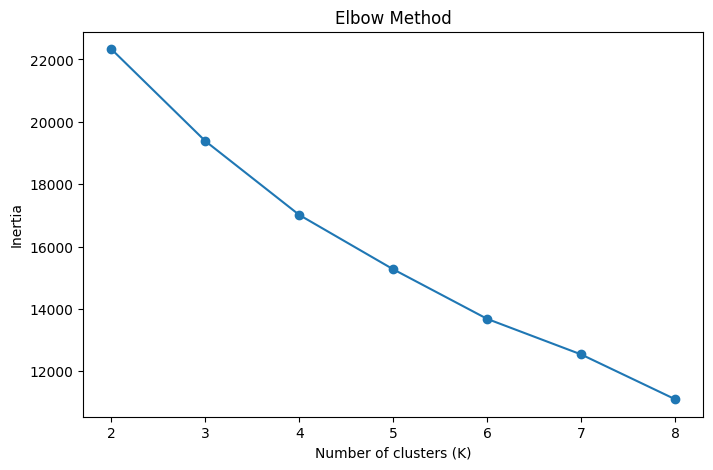

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    cluster_results['K'],
    cluster_results['Inertia'],
    marker='o'
)

plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

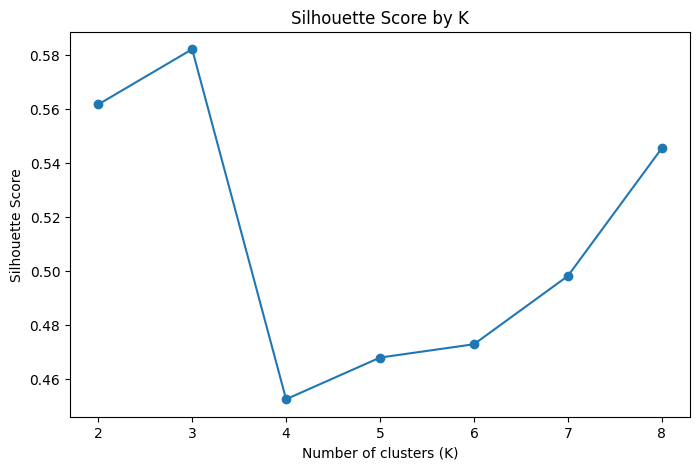

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    cluster_results['K'],
    cluster_results['Silhouette_Score'],
    marker='o'
)

plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K')

plt.show()

In [ ]:
best_k = int(
    cluster_results.loc[
        cluster_results['Silhouette_Score'].idxmax(),
        'K'
    ]
)

print("Best K based on silhouette score:", best_k)

Best K based on silhouette score: 3


In [ ]:
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=50
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

df['Cluster'] = cluster_labels + 1

print(df['Cluster'].value_counts().sort_index())

Cluster
1    2631
2     312
3      87
Name: count, dtype: int64


In [ ]:
cluster_profile = pd.DataFrame(
    X_imputed.copy()
)

cluster_profile['Cluster'] = df['Cluster'].values

cluster_summary = (
    cluster_profile
    .groupby('Cluster')[final_features]
    .mean()
    .round(2)
)

cluster_summary

,Seasonality_Segment,EA_Segment,Revenue_Bucket,Profit_Bucket,Market_Potential_Segment,Churn_Segment,Volume_Segment,Density_Segment,Propensity
Cluster,,,,,,,,,
1,2.01,2.95,1.02,3.00,2.02,2.00,2.49,2.76,1.95
2,2.02,2.48,2.16,2.99,3.16,2.10,2.40,2.53,2.49
3,2.02,2.71,1.01,1.17,1.95,1.93,2.14,2.72,1.78


In [ ]:
cluster_size = (
    df['Cluster']
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_size.columns = [
    'Cluster',
    'Customers'
]

cluster_size['Percentage'] = (
    cluster_size['Customers'] /
    len(df) * 100
).round(2)

cluster_size

,Cluster,Customers,Percentage
0,1,2631,86.83
1,2,312,10.30
2,3,87,2.87


In [ ]:
country_cluster = pd.crosstab(
    df['Cluster'],
    df['Country'],
    normalize='index'
).round(3)

country_cluster

Country,ABW,ANT,ARG,AUS,AUT,BES,BHS,BMU,CAN,CHL,...,No Address Found,PAN,PER,PRY,SXM,TCA,URY,USA,VEN,VGB
Cluster,,,,,,,,,,,,,,,,,,,,,
1,0.005,0.001,0.001,0.002,0.0,0.0,0.001,0.0,0.057,0.01,...,0.074,0.026,0.024,0.003,0.003,0.001,0.002,0.753,0.001,0.001
2,0.000,0.000,0.000,0.000,0.0,0.0,0.000,0.0,0.042,0.00,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.958,0.000,0.000
3,0.000,0.000,0.000,0.000,0.0,0.0,0.000,0.0,0.023,0.00,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.977,0.000,0.000


In [ ]:
city_cluster = pd.crosstab(
    df['Cluster'],
    df['City'],
    normalize='index'
).round(3)

city_cluster

City,79111 Freiburg im Breisgau,ABBOTSFORD,ACOMA,ADA,ADDISON,AGENCY VILLAGE,AIRWAY HEIGHTS,AJAX,ALBUQUERQUE,ALGODONES,...,YEARINGTON,YERINGTON,YONKERS,YORK,YORKTON,YREKA,YUMA,Yale,Youngstown,ZEPHYR COVE
Cluster,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.000,0.0,0.0,0.001,0.0,0.001,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001,0.000,0.0
2,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.010,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.003,0.0
3,0.0,0.0,0.0,0.011,0.0,0.0,0.000,0.0,0.000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.0


In [ ]:
outlier_by_cluster = pd.crosstab(
    df['Cluster'],
    df['Outlier_Flag']
)

outlier_by_cluster

Outlier_Flag,Normal,Outlier
Cluster,,
1,2608,23
2,207,105
3,63,24


In [ ]:
business_profile = (
    df.groupby('Cluster')
      .agg(
          Customers=('Customer_ID', 'count'),
          Avg_Revenue=('Revenue_Bucket', lambda x:
                       x.map({'L':1, 'M':2, 'H':3}).mean()),
          Avg_Volume=('Volume_Segment', lambda x:
                      x.map({'Low':1, 'Medium':2, 'High':3}).mean()),
          Avg_Density=('Density_Segment', lambda x:
                       x.map({'Low':1, 'Medium':2, 'High':3}).mean()),
          Avg_Market_Potential=('Market_Potential_Segment', lambda x:
                                x.map({'L':1, 'M':2, 'H':3, 'VH':4}).mean())
      )
      .round(2)
)

business_profile

,Customers,Avg_Revenue,Avg_Volume,Avg_Density,Avg_Market_Potential
Cluster,,,,,
1,2631,1.07,2.34,2.64,2.07
2,312,2.17,2.40,2.36,3.25
3,87,1.01,1.96,2.53,1.89


In [ ]:
output_columns = [
    'Customer_ID',
    'Country',
    'City',
    'Cluster',
    'Outlier_Flag'
]

final_output = df[output_columns].copy()

final_output.to_excel(
    'Customer_Segmentation_Final.xlsx',
    index=False
)

print("File created successfully!")
print(final_output.head())

File created successfully!
  Customer_ID Country         City  Cluster Outlier_Flag
0  Accoount 1     CAN  MISSISSAUGA        1       Normal
1  Accoount 2     USA       GRETNA        1       Normal
2  Accoount 3     USA      LaPlace        1       Normal
3  Accoount 4     USA         RENO        1       Normal
4  Accoount 5     USA       Sparks        1       Normal


# Insights


1. Customer Segmentation :
The K-Means analysis identified 3 distinct customer segments based on purchasing behavior, revenue, profitability, market potential, volume, density and purchase propensity.

2. Cluster 1 – Core / Stable Customer Base
Represents the largest customer group (2,631 customers).
These customers form the company's core customer base and should be prioritized for retention and relationship management.
Focus on maintaining engagement, repeat purchases and preventing movement to lower-value segments.
3. Cluster 2 – High-Value / Growth Customers
Contains 312 customers with relatively stronger revenue, market potential and purchase propensity.
This segment represents the most attractive growth opportunity.
Recommended actions: upselling, cross-selling, premium offerings and deeper account-level engagement.
4. Cluster 3 – Lower-Value / Potentially At-Risk Customers
Contains 87 customers and shows relatively lower revenue, profitability and purchase propensity.
These customers require further investigation to understand barriers to purchase and potential reasons for low engagement.
Recommended actions: targeted re-engagement, customized offers and account-level diagnosis.